In [1]:
import math
from pathlib import Path
from typing import Tuple

from marslab.geom import get_coordinate_system_properties
from marslab.imgops.imgutils import normalize_range
import marslab.parse as mp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pdr
from scipy.spatial.transform import Rotation
from scipy.optimize import newton

%matplotlib qt

In [2]:
product_root = Path('/datascratch/zcam_data/products/')
sol = 92
sol_dir = Path(product_root, str(sol).zfill(4))
iof_dir = Path(sol_dir, "iof")
xyr_dir = Path(sol_dir, "xyr")

In [3]:
ncam_site_drive = set(
    map(lambda x: (mp.site(x.name), mp.drive(x.name)), xyr_dir.iterdir())
)
xcam_site_drive = set(
    map(lambda x: (mp.site(x.name), mp.drive(x.name)), iof_dir.iterdir())
)
ncam_site_drive, xcam_site_drive

({(4, 136)}, {(4, 136)})

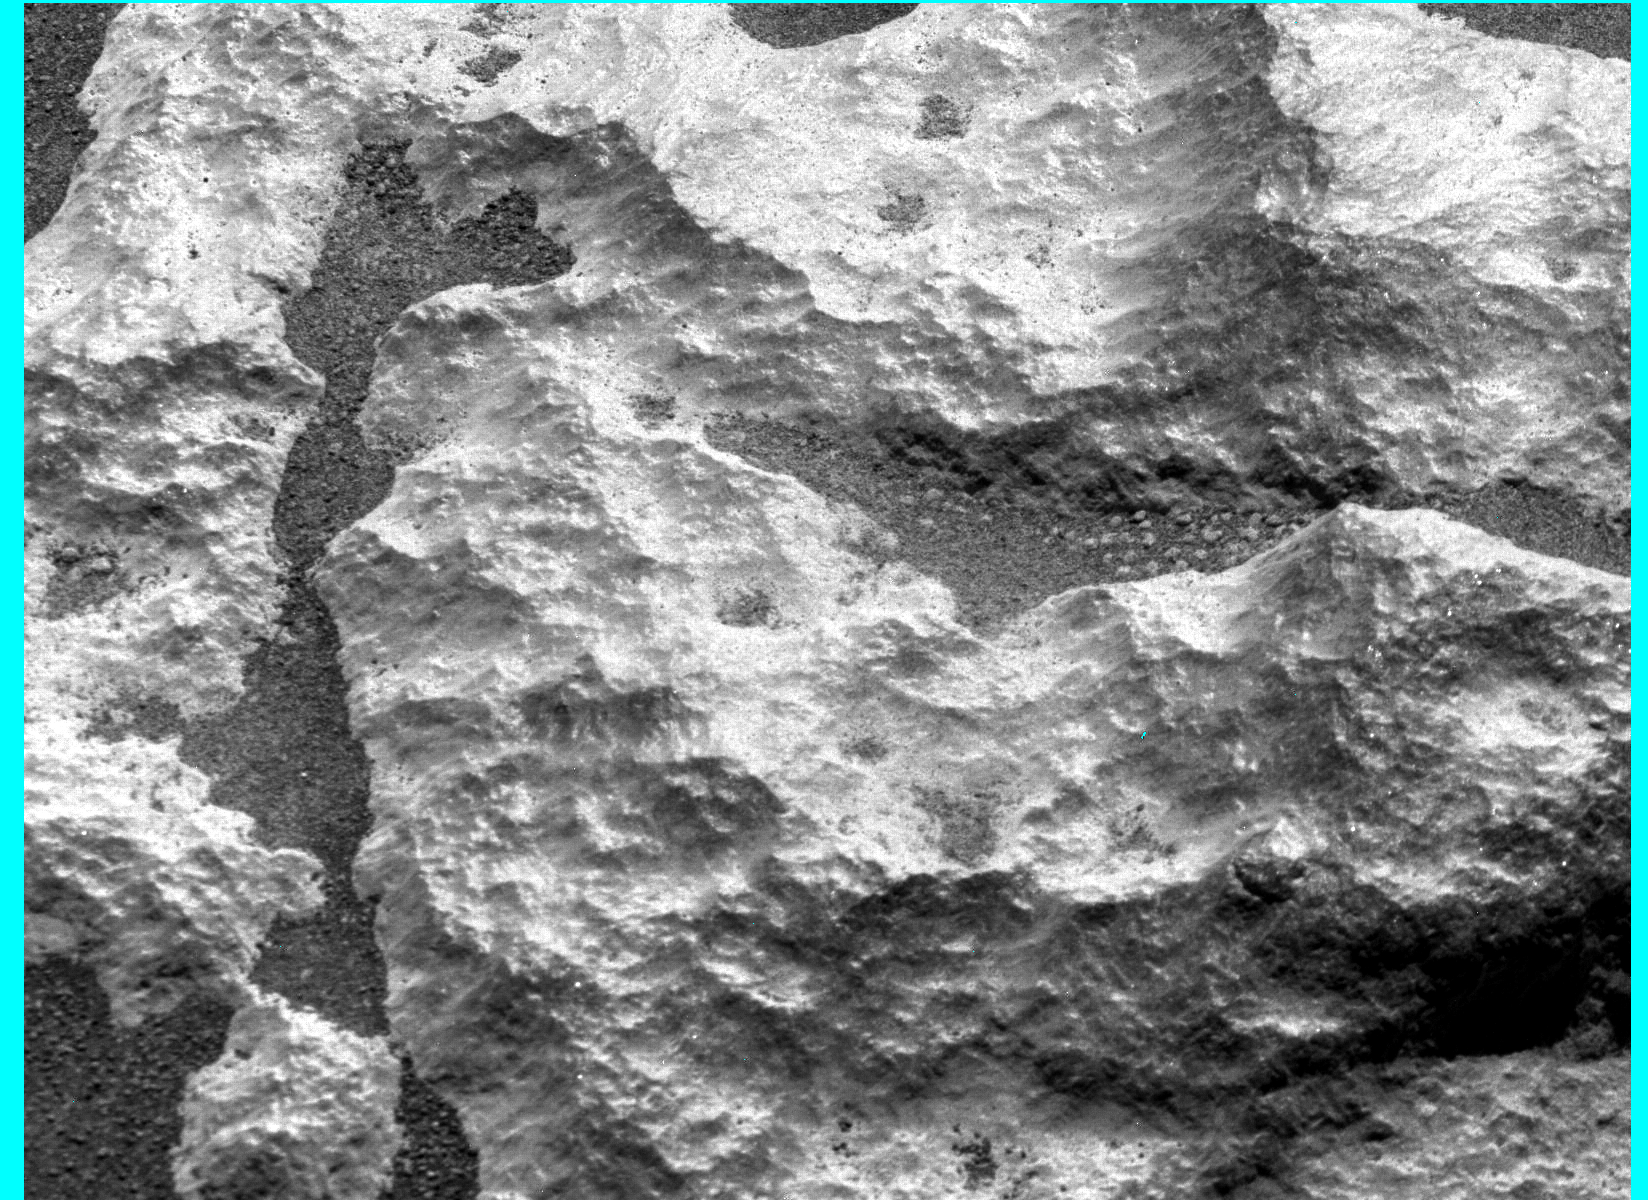

In [4]:
r2_data = pdr.read(
    [p for p in iof_dir.iterdir() if p.name.startswith("ZR2")][0]
)
r2_data.show('IMAGE')

In [250]:
def open_attached(path):
    return pdr.open(path, label_fn=path, skip_existence_check=True)


def get_valid_edges(im: np.ma.MaskedArray):
    if len(im.shape) == 3:
        vy, vx = np.nonzero(np.sum(~im.mask, axis=-1))
    else:
        vy, vx = np.nonzero(~im.mask)
    valid = np.vstack([vy, vx]).T
    v_offset = np.abs(vy - im.shape[0] / 2)
    t_offset = vy
    b_offset = np.abs(vy - im.shape[0])
    h_offset = np.abs(vx - im.shape[1] / 2)
    l_offset = vx
    r_offset = np.abs(vx - im.shape[1])
    return {
        'top': valid[(t_offset + h_offset).argmin()],
        'bottom': valid[(b_offset + h_offset).argmin()],
        'left': valid[(v_offset + l_offset).argmin()],
        'right': valid[(v_offset + r_offset).argmin()]
    }


def get_cahvore(data: pdr.Data, group="GEOMETRIC_CAMERA_MODEL"):
    block = data.metablock(group)
    components = {'reference_frame': block.get('REFERENCE_COORD_SYSTEM_NAME')}
    for comp_ix, id_ in enumerate(block["MODEL_COMPONENT_ID"]):    
        components[id_] = np.array(block[f"MODEL_COMPONENT_{comp_ix + 1}"])
    components['az_fov'] = data.metaget('AZIMUTH_FOV')['value']
    components['el_fov'] = data.metaget('ELEVATION_FOV')['value']
    components['pix_w'] = data.metaget_('LINE_SAMPLES')
    components['pix_h'] = data.metaget_('LINES')
    return components


def check_in_bounds(nxyz, nav_c, zcam_a):
    edges_ij = get_valid_edges(nxyz)
    nav_edgerays = {
        k: nxyz[v[0], v[1]] - nav_c for k, v in edges_ij.items()
    }
    nz_edge_cross = {
        k: np.cross(edgeray, zcam_a) for k, edgeray in nav_edgerays.items()
    }
    in_bounds_j = (np.sign(nz_edge_cross['top']) != np.sign(nz_edge_cross['bottom']))[1]
    in_bounds_i = (np.sign(nz_edge_cross['left']) != np.sign(nz_edge_cross['right']))[2]
    if in_bounds_i and in_bounds_j:
        return True
    return False


def derive_cahvore_properties(cahvore):
    for ax in ('H', 'V'):
        cahvore[f'{ax}_image'] = (
            cahvore[ax] - np.dot(cahvore['A'], cahvore[ax]) * cahvore['A']
        )
        cahvore[f'{ax}s'] = np.linalg.norm(np.cross(cahvore['A'], cahvore[ax]))
        cahvore[f'{ax}c'] = np.dot(cahvore['A'], cahvore[ax])
    cahvore['dpp_H'] = cahvore['az_fov'] / cahvore['pix_w']
    cahvore['dpp_V'] = cahvore['el_fov'] / cahvore['pix_h']
    for ax in ('H', 'V', 'A'):
        cahvore[f'{ax}u'] = cahvore[ax]/np.linalg.norm(cahvore[ax])
    return cahvore


# rough! and maybe unnecessary?
def ij_to_ray(i, j, cahv):
    i_off = i - cahv['Hc']
    j_off = j - cahv['Vc']
    rot_H = cahv['Hu'] * i_off * cahv['dpp_H']
    rot_V = cahv['Vu'] * j_off * cahv['dpp_V']
    rotate = Rotation.from_rotvec((rot_H, rot_V), degrees=True)
    return np.mean(rotate.apply(cahv['A']), axis=0)


# maybe?
def rough_valid_area(xyzmap, cahvor, slop = 0.8):
    relative_position_vecs = (xyzmap - cahvor['C'])
    rel_pos_mag = np.linalg.norm(relative_position_vecs, axis=2)
    rel_pos_u = np.einsum('ijk,ij->ijk', relative_position_vecs, 1 / rel_pos_mag)
    # plt.imshow(rel_pos_u)  # pretty!
    off_comp_h = np.dot(cahvor['Au'] - rel_pos_u, cahvor['Hu'])
    off_comp_v = np.dot(cahvor['Au'] - rel_pos_u, cahvor['Vu'])
    off_h_deg = np.abs(np.degrees(np.arcsin(off_comp_h)))
    off_v_deg = np.abs(np.degrees(np.arcsin(off_comp_v)))
    return np.nonzero(
        np.logical_and(
            off_h_deg < (cahvor['az_fov'] / (2 - slop)),
            off_v_deg < (cahvor['el_fov'] / (2 - slop))
        )
    )

def prune_xyzmap(xyzmap: np.ma.MaskedArray, cahvore: dict, slop: float=0.8):
    xyz = xyzmap[rough_valid_area(xyzmap, cahvore, slop=slop)]
    assert not xyz.mask.any(), "invalid pixels have entered the xyzmap"
    return xyz.data


def xyz2ij(xyz, cahvore):
    relative_positions = xyz - cahvore['C']
    omegas = np.dot(relative_positions, cahvore['O'])
    w_omegas = np.einsum('ij,i->ij', np.array([cahvore['O'] for _ in omegas]), omegas)
    lambda3s = relative_positions - w_omegas
    taus = np.einsum('ij,ij->i', lambda3s, lambda3s) / omegas ** 2
    r1, r2, r3 = cahvore['R']
    mus = r1 + r2 * taus + r3 * taus ** 2
    pps = np.einsum('ij,i->ij', lambda3s, mus) + xyz
    pp_cs = pps - cahvore['C']
    ppcs_dot_a = np.dot(pp_cs, cahvore['A'])
    ijvec = np.vstack(
        [
            np.dot(pp_cs, cahvore['H']) / ppcs_dot_a - 1,
            np.dot(pp_cs, cahvore['V']) / ppcs_dot_a - 1,
        ]
    ).T
    return np.round(ijvec).astype(np.int32)


def select_valid_pixels(ij, cahvore):
    ij_validmask = (
        np.all(ij > 0, axis=1)
        & (ij[:, 0] <= zc['pix_w'] - 1) 
        & (ij[:, 1] <= zc['pix_h'] - 1) 
    )
    return np.nonzero(ij_validmask)


def select_and_map_coordinates(xyzmap, target_cahvore):
    xyz_candidates = prune_xyzmap(xyzmap, target_cahvore)  # optimization step
    ij_candidates = xyz2ij(xyz_candidates, target_cahvore)
    valid_index = select_valid_pixels(ij_candidates, target_cahvore)
    ij = ij_candidates[valid_index].T
    xyz = xyz_candidates[valid_index].T
    return {'i': ij[0], 'j': ij[1], 'x': xyz[0], 'y': xyz[1], 'z': xyz[2]}

In [6]:
xyrs = tuple(filter(lambda f: f.suffix == ".IMG", xyr_dir.iterdir()))

In [ ]:
# xyr = open_attached(xyrs[1])
# nav_cahvore = get_cahvore(xyr)
# (xyr.metaget('STEREO_PRODUCT_ID'), xyr.metaget('SOURCE_PRODUCT_ID'), xyr.metaget('INPUT_PRODUCT_ID'))

In [7]:
nav_input = pdr.read(
    '/datascratch/zcam_data/products/0092/nav/NLFC0092_0675117098_000RASLN0040136NCAM00699_0A00LLJ01.IMG'
)
navim = normalize_range(np.moveaxis(nav_input.IMAGE, 0, 2), (0, 1), 1)
plt.figure()
plt.imshow(navim)
# plt.figure()
# plt.imshow(np.sqrt(nxyz[:, :, 0] + 1))

In [251]:
zc = derive_cahvore_properties(get_cahvore(r2_data))
for xyr_file in xyrs:
    xyr = open_attached(xyr_file)
    nc = get_cahvore(xyr)
    nxyz = np.moveaxis(xyr.get_scaled('IMAGE'), 0, 2)
#     plt.figure()
#     plt.imshow(np.sqrt(nxyz[:, :, 0] + 1))
#     plt.title(xyr_file)
    if check_in_bounds(nxyz, nc['C'], zc['A']) is True:
        print(xyr)
        break

pdr.Data(/datascratch/zcam_data/products/0092/xyr/NRFC0092_0675115592_000XYRLN0040136NCAM00698_0A00LLJ01.IMG)
keys=['LABEL', 'IMAGE_HEADER', 'IMAGE', 'DESCRIPTION']
not yet loaded: ('LABEL', 'IMAGE_HEADER', 'DESCRIPTION')


In [470]:
coords = select_and_map_coordinates(nxyz, zc)

/tmp/ipykernel_129303/1676007998.py:76: RuntimeWarning: divide by zero encountered in divide
  rel_pos_u = np.einsum('ijk,ij->ijk', relative_position_vecs, 1 / rel_pos_mag)


In [472]:
coords

{'i': array([   3,   11,   19, ..., 1628, 1635, 1642], dtype=int32),
 'j': array([   6,    5,    5, ..., 1194, 1194, 1193], dtype=int32),
 'x': array([3.048543 , 3.047619 , 3.0469759, ..., 2.7058976, 2.7066584,
        2.7071192], dtype=float32),
 'y': array([0.63943404, 0.64097124, 0.6424904 , ..., 0.9127563 , 0.9141397 ,
        0.9154989 ], dtype=float32),
 'z': array([-0.17662111, -0.17739767, -0.17794402, ..., -0.16924077,
        -0.16851039, -0.16807549], dtype=float32)}

In [340]:
interp_tracker = np.full(r2_data.IMAGE.shape, 1, np.float32)

In [341]:
interp_tracker[ji[:, 0], ji[:, 1]] = 0

In [305]:
# from marslab.imgops.imgutils import enhance_color
# plt.imshow(enhance_color(nmask, (0, 1), 1), interpolation='none')

In [342]:
from scipy.interpolate import griddata

In [355]:
missing_ji = np.nonzero(interp_tracker)
gridded_x = griddata(ji, xyz[:, 0], missing_ji)

In [357]:
x_array = np.empty(r2_data.IMAGE.shape, np.float32)
x_array[ji[:, 0], ji[:, 1]] = xyz[:, 0]
x_array[missing_ji] = gridded_x

In [359]:
gridded_y = griddata(ji, xyz[:, 1], missing_ji)
y_array = np.empty(r2_data.IMAGE.shape, np.float32)
y_array[ji[:, 0], ji[:, 1]] = xyz[:, 1]
y_array[missing_ji] = gridded_y

In [360]:
gridded_z = griddata(ji, xyz[:, 2], missing_ji)
z_array = np.empty(r2_data.IMAGE.shape, np.float32)
z_array[ji[:, 0], ji[:, 1]] = xyz[:, 2]
z_array[missing_ji] = gridded_z

In [400]:
alpha = 0.6
xyz_filled = np.dstack([x_array, y_array, z_array])
xyz_filled = np.ma.masked_invalid(xyz_filled)
stretched = enhance_color(xyz_filled, (0, 1), (1))
stretched = np.dstack([stretched, np.full_like(x_array, alpha)])

In [377]:
image = normalize_range(r2_data.get_scaled('IMAGE'), (0, 1), 1)
image_rgb = np.dstack([image] * 3)

In [404]:
from marslab.imgops.render import flatten_into_figure
flat = flatten_into_figure([image_rgb, stretched])

/opt/mambaforge/envs/asdf/lib/python3.10/site-packages/matplotlib/cm.py:478: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


In [410]:
distance = np.linalg.norm(xyz_filled, axis=2)

In [412]:
fig, ax = plt.subplots()

In [413]:
ax.imshow(distance, cmap='cividis')

AttributeError: 'Figure' object has no attribute 'shape'

In [ ]:
griddata(ji[:, 0], ji[:, 1])

In [321]:
ji[:, 0].argsort()

array([   37,   598,    77, ..., 33434, 33333, 31975])

In [322]:
ji[:, 1].argsort()

array([30694, 25980,  2802, ..., 15284, 26195, 19968])

In [319]:
ji[:, 0]

array([   6,    5,    5, ..., 1194, 1194, 1193], dtype=int16)

In [318]:
RegularGridInterpolator((ji[:, 0], ji[:, 1]), xyz[0])

ValueError: The points in dimension 0 must be strictly ascending or descending

In [309]:
interp2d?

In [177]:
ix = 11022
cahvore = zc
relpos, xyz = relative_positions[ix], possible_xyz[ix]
omega = np.dot(relpos, cahvore['O'])
wo = omega * cahvore['O']
lambda3 = relpos - wo
tau = np.dot(lambda3, lambda3) / omega ** 2
r1, r2, r3 = cahvore['R']
mu = r1 + r2 * tau + r3 * tau ** 2
pp = mu * lambda3 + xyz
pp_c = pp - cahvore['C']
ppc_dot_a = np.dot(pp_c, cahvore['A'])
res = {
    'ij': (
        np.dot(pp_c, cahvore['H']) / ppc_dot_a - 1,
        np.dot(pp_c, cahvore['V']) / ppc_dot_a - 1
    ), 
    'xyz': xyz
}

In [70]:
## i think this works, though!


# what do a lot of these variables stand for? incomprehensible
def xyz2ij(xyz, relpos, cahvore):
    omega = np.dot(relpos, cahvore['O'])
    wo = omega * cahvore['O']
    lambda3 = relpos - wo
    tau = np.dot(lambda3, lambda3) / omega ** 2
    r1, r2, r3 = cahvore['R']
    mu = r1 + r2 * tau + r3 * tau ** 2
    pp = mu * lambda3 + xyz
    pp_c = pp - cahvore['C']
    ppc_dot_a = np.dot(pp_c, cahvore['A'])
    return {
        'ij': (
            np.dot(pp_c, cahvore['H']) / ppc_dot_a - 1,
            np.dot(pp_c, cahvore['V']) / ppc_dot_a - 1
        ), 
        'xyz': xyz
    }

In [74]:
omega = np.dot(relative_positions, zc['O'])

masked_array(data=[2.95203671, 2.95173555, 2.95135186, ..., 2.57909383,
                   2.57922587, 2.57977207],
             mask=False,
       fill_value=1e+20)

In [72]:
located = [xyz2ij(xyz, relpos, zc) for xyz, relpos in zip(possible_xyz, relative_positions)]

In [56]:
valid_ij = []
for coord in ij:
    if not 0 <= coord[0] <= 1648:
        continue
    if not 0 <= coord[1] <= 1200:
        continue
    valid_ij.append(coord)

In [58]:
len(valid_ij)

33485

In [50]:
ij[-10]

(2315.899380897797, 1554.8100263298197)

In [54]:
r2_data.IMAGE.shape

(1200, 1648)

In [ ]:
# maybe unnecssary?
zcam_edges = get_valid_edges(r2_data.get_scaled('IMAGE'))
zcam_edge_rays = {
    k: ij_to_ray(yx[1], yx[0], zc)
    for k, yx in zcam_edges.items()
}

In [ ]:
# not sure this cross product is useful
# pos_cross_a_mag = np.linalg.norm(pos_cross_a, axis=2)
# pos_cross_a_u = np.einsum('ijk,ij->ijk', pos_cross_a, 1 / pos_cross_a_mag)
# i think taking these dot products is incoherent...
# pos_cross_a_dot_h = np.dot(pos_cross_a_u, zc['Hu'])
# pos_cross_a_dot_v = np.dot(pos_cross_a_u, zc['Vu'])
# not sure these dot products are useful
# pos_dot_h = np.dot(rel_pos_u, zc['Hu'])
# pos_dot_v = np.dot(rel_pos_u, zc['Vu'])

In [ ]:
plt.imshow(rough_valid_area)
bigmask = np.logical_or(nxyz.mask, np.dstack([~rough_valid_area]*3))
nxyz_v = nxyz.copy()
nxyz_v.mask = bigmask
nxyz_v[nxyz_v.mask] = 0
plt.figure()
plt.imshow(nxyz_v)

In [ ]:
from scipy.spatial.transform import Rotation

In [ ]:
Rotation.from_rotvec()

In [ ]:
plt.imshow(np.sqrt(nxyz[:, :, 0]))

see: https://pds-imaging.jpl.nasa.gov/data/mer/spirit/mer2no_0xxx/document/geometric_cm.txt

so what is this ij_to_ray?

in CAHV model strictly: 

```
Given a 3D point P, the image coordinates may be computed as

             (P-C)*H         (P-C)*V 
         X = -------     Y = -------        
             (P-C)*A         (P-C)*A 

         (Note: * = vector dot product)
```

the dot product is of course not injective, so these equations cannot simply be inverted.

note, though, that A, H, V are _close_ to mutually orthogonal even given the ORE parameters...


```
A projection of this vector into the image plane,
called H', shows how the horizontal image dimension (the rows)
are oriented in 3D.The magnitude of this projection is, for an
ideal thin lens, the distance between the lens center and the
image plane, as measured in horizontal pixels; this value is
called the Horizontal Scale, and is often written as Hs.
(Contrary to what has been suggested elsewhere, Hs is not the focal length.)
[and then the same is true for V/vertical pixels]

```

```
H' = H-(A*H)A     Hs = |AxH|    Hc = A*H
```

```
Note that H' and V' are not necessarily exactly perpendicular to each
other. The angle between them, theta, is a measure of the spatial
relationship of the rows and columns. They are usually very close to
perpendicular, but have sometimes been observed to fall more than a
standard deviation away from that ideal.

                             (   VxH*A   ) 
               Theta = arctan(-----------) 
                             ((AxV)*(AxH))
```

In [ ]:
zcam_cahvore = derive_cahvore_properties(zcam_cahvore)

In [ ]:
zcam_cahvore

In [ ]:
zcam_cahvore['H_image'] / zcam_cahvore['Hs']

In [ ]:
np.linalg.norm(zcam_cahvore['V'])

In [ ]:
plt.imshow(r2.get_scaled('IMAGE'))

In [ ]:
# so i think we're talking about like y=2313, x=2680 for center of zcam image in xyr image coords

In [ ]:
xyz_rov = nxyz[2313, 2680].data

In [ ]:
xyz_rov

In [ ]:
plt.figure()
plt.imshow(np.clip(nxyz[:, :, 1], 0.2, 0.8))

In [ ]:
zcam_cahvore['C'], zcam_cahvore['A']

In [ ]:
test_position = zcam_cahvore['C'] + zcam_cahvore['A'] * 4
# zcam_cahvore['H'], zcam_cahvore['V']

In [ ]:
h_hat = zcam_cahvore['H'] / np.linalg.norm(zcam_cahvore['H'])
v_hat = zcam_cahvore['V'] / np.linalg.norm(zcam_cahvore['V'])
a_hat = zcam_cahvore['A'] / np.linalg.norm(zcam_cahvore['A'])

In [ ]:
az_fov = r2

In [ ]:
  AZIMUTH_FOV                     = 6.36042 <deg>
  ELEVATION_FOV                   = 4.63709 <deg>
  BAYER_METHOD                    = IDENTITY
  CFA_TYPE                        = BAYER_RGGB
  CFA_VENUE                       = ONBOARD
  DETECTOR_FIRST_LINE             = 1
  DETECTOR_FIRST_LINE_SAMPLE      = 1
  DETECTOR_LINES                  = 1200
  DETECTOR_LINE_SAMPLES           = 1648

In [ ]:
np.degrees(np.arccos(np.dot(a_hat, v_hat)))

In [ ]:
len(np.nonzero(~nxyz.mask)[0]) * 200

In [ ]:
i, j

In [ ]:
# # this should be cool but in fact will need more work to be cool
# from marslab.imgops.imgutils import enhance_color
# im = np.moveaxis(im, 0, 2)
# display = enhance_color(im, (0, 1), 1)
# plt.imshow(display)